# 02. LIME Explanations

## 📚 Learning Objectives

By completing this notebook, you will:
- Apply LIME for local interpretability
- Generate and interpret local explanations
- Compare LIME with other XAI methods

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

---

# 02. LIME Explanations

## 🚨 THE PROBLEM: We Need Faster, Simpler Explanations

**Remember the limitation from the previous notebook?**

We learned SHAP for explaining model predictions. But we discovered:

**What if we need a simpler, faster explanation method that works with any model?**

**The Problem**: Sometimes we need:
- ❌ **Faster explanations** (SHAP can be slow for large datasets)
- ❌ **Simpler methods** (easier to understand and implement)
- ❌ **Model-agnostic approaches** (work with any black-box model)
- ❌ **Local explanations** (explain individual predictions quickly)

**We've learned:**
- ✅ How to use SHAP for model explanations (Notebook 1)
- ✅ How to generate local and global explanations
- ✅ Feature importance concepts

**But we haven't learned:**
- ❌ How to use **LIME** for fast local explanations
- ❌ How to provide **simpler explanations** for non-technical users
- ❌ How to use **model-agnostic** explanation methods
- ❌ How to **compare different explanation methods**

**We need LIME (Local Interpretable Model-agnostic Explanations)** to:
1. Provide fast local explanations
2. Work with any black-box model
3. Offer simpler, more intuitive explanations
4. Enable real-time explainability

**This notebook solves that problem** by teaching you LIME for fast, model-agnostic explanations!

---

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Example 1: SHAP Explanations** - Understanding explainability basics
- ✅ **Basic Python knowledge**: Functions, data manipulation, ML concepts
- ✅ **Basic ML knowledge**: Model training, predictions

**If you haven't completed these**, you might struggle with:
- Understanding why we need alternative explanation methods
- Knowing how LIME differs from SHAP
- Understanding local interpretability concepts

---

## 🔗 Where This Notebook Fits

**This is the SECOND example in Unit 4** - it teaches you faster, simpler explanations!

**Why this example SECOND?**
- **Before** you can use LIME effectively, you need to understand SHAP (Example 1)
- **Before** you can compare methods, you need multiple approaches
- **Before** you can use counterfactuals, you need local explanations

**Builds on**: 
- 📓 Example 1: SHAP Explanations (we learned SHAP, now we learn LIME!)

**Leads to**: 
- 📓 Example 3: Counterfactual Analysis (what-if explanations)
- 📓 Example 4: Accountability Frameworks (accountability structures)
- 📓 Example 5: Human-in-the-Loop (HITL approaches)
- 📓 Example 6: Transparency Tools (transparency frameworks)

**Why this order?**
1. LIME provides **alternative approach** (complements SHAP)
2. LIME enables **faster explanations** (critical for real-time systems)
3. LIME shows **model-agnostic** methods (works with any model)

---

## The Story: Fast and Simple Explanations

Imagine you're a loan officer using AI to approve loans. **Before** LIME, you'd use SHAP but it might be too slow for real-time decisions. **After** using LIME, you get fast, simple explanations that show which factors matter most - quick and understandable!

Same with AI: **Before** we have SHAP but it may be slow, now we learn LIME - fast local explanations using simple linear models! **After** LIME, we can explain predictions quickly for any model!

---

## Why LIME Explanations Matter

LIME explanations are essential for ethical AI:
- **Speed**: Fast explanations for real-time systems
- **Simplicity**: Easy to understand for non-technical users
- **Model-Agnostic**: Works with any black-box model
- **Local Focus**: Explains individual predictions clearly
- **Flexibility**: Works with tabular, text, and image data

## Learning Objectives
1. Understand LIME and how it differs from SHAP
2. Learn how to generate LIME explanations
3. Apply LIME to tabular data
4. Understand local interpretability concepts
5. Compare LIME vs SHAP approaches
6. Use LIME for real-time explainability

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

## Part 1: Same Model, Different Explainer

LIME explains one prediction by fitting a *simple local surrogate model* around the
instance: it perturbs the input, watches the black-box's answers, and fits a small linear
model that is faithful *near this instance only*. We reuse the loan-approval setup.

In [1]:
# Why start here: explanation tools need a real trained model to interrogate -
# we build a loan-approval model whose true logic WE know, so we can check the explanations.

# Build a small loan-approval dataset and train the model we will explain
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

np.random.seed(42)
n = 800
X = pd.DataFrame({
    'income':          np.random.normal(55, 18, n).clip(10, 150),     # k$/year
    'debt_ratio':      np.random.uniform(0.05, 0.6, n),               # debt/income
    'years_employed':  np.random.randint(0, 25, n),
    'credit_history':  np.random.normal(650, 80, n).clip(350, 850),   # score
})
# The ground-truth rule: approval is driven by income (+), debt (-),
# tenure (+), and credit history (+). Explanations should rediscover this.
score = (0.03*(X['income']-55) - 4.0*(X['debt_ratio']-0.3)
         + 0.05*X['years_employed'] + 0.008*(X['credit_history']-650))
y = (score + np.random.normal(0, 0.35, n) > 0).astype(int)   # 1 = approved

# Hold out a test set, then fit the classifier we will explain.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
                                                    random_state=42, stratify=y)
model = RandomForestClassifier(n_estimators=150, random_state=42)
model.fit(X_train, y_train)
print(f"Loan-approval model trained. Test accuracy: "
      f"{accuracy_score(y_test, model.predict(X_test)):.3f}")
print(f"Approval rate in data: {y.mean():.1%}")

Loan-approval model trained. Test accuracy: 0.905
Approval rate in data: 66.0%


Applicant #0: approval probability 0.15
income             64.27
debt_ratio          0.41
years_employed      5.00
credit_history    503.33

LIME explanation (rule -> weight toward 'approved'):
  credit_history <= 594.71            -0.3946
  years_employed <= 6.00              -0.1271
  54.77 < income <= 66.24             +0.1131
  0.33 < debt_ratio <= 0.46           -0.0945


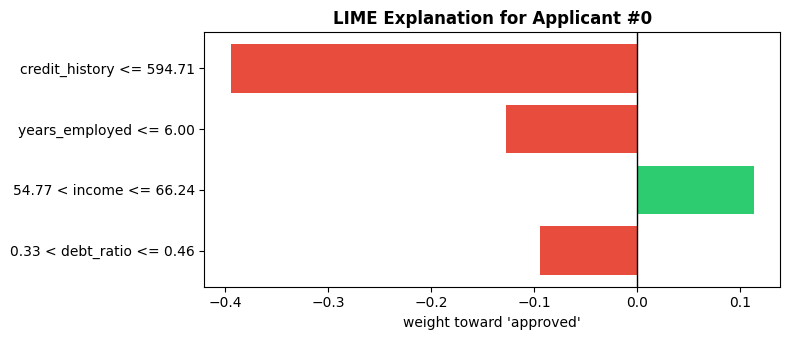


SHAP vs LIME on the same instance:
  - SHAP: additive attributions with game-theoretic guarantees; slower
  - LIME: interpretable RULES from a local surrogate; fast, but results
    vary with the random perturbations (run twice -> slightly different)
  - Both are model-agnostic in spirit; both explain ONE prediction here


In [2]:
# Why LIME: it explains ONE prediction by fitting a simple surrogate model
# to the black box's behavior in the neighborhood of that instance.

# Step 2: LIME local explanation for one applicant
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')  # silence sklearn feature-name warning from LIME's numpy inputs

# The explainer perturbs feature values around an instance and watches how
# the model's output changes - the surrogate is trained on those perturbations.
explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=list(X_train.columns),
    class_names=['denied', 'approved'],
    mode='classification',
    random_state=42,
)

i = 0
exp = explainer.explain_instance(X_test.iloc[i].values,
                                 model.predict_proba, num_features=4)
proba = model.predict_proba(X_test.iloc[[i]])[0, 1]
print(f"Applicant #{i}: approval probability {proba:.2f}")
print(X_test.iloc[i].round(2).to_string())

pairs = exp.as_list()
print("\nLIME explanation (rule -> weight toward 'approved'):")
for rule, weight in pairs:
    print(f"  {rule:<35} {weight:+.4f}")

# Chart the rules: green rules pushed toward approval, red toward denial.
fig, ax = plt.subplots(figsize=(8, 3.5))
rules = [p[0] for p in pairs][::-1]
weights = [p[1] for p in pairs][::-1]
ax.barh(rules, weights,
        color=['#e74c3c' if w < 0 else '#2ecc71' for w in weights])
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel("weight toward 'approved'")
ax.set_title(f'LIME Explanation for Applicant #{i}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nSHAP vs LIME on the same instance:")
print("  - SHAP: additive attributions with game-theoretic guarantees; slower")
print("  - LIME: interpretable RULES from a local surrogate; fast, but results")
print("    vary with the random perturbations (run twice -> slightly different)")
print("  - Both are model-agnostic in spirit; both explain ONE prediction here")

---

## 🚫 When LIME Explanations Hit a Limitation

### The Limitation We Discovered

We've learned LIME for fast, local explanations. **But there's still a challenge:**

**What if we need to understand "what if" scenarios - how would predictions change if features were different?**

LIME works well when:
- ✅ We need fast local explanations
- ✅ We want to understand current predictions
- ✅ We can use model-agnostic methods

**But we also need:**
- ❌ **Counterfactual explanations** (what-if scenarios)
- ❌ **Actionable insights** (what to change to get different outcomes)
- ❌ **Alternative scenarios** (how predictions would change)
- ❌ **Causal reasoning** (understanding cause-effect relationships)

### Why This Is a Problem

When we only have feature importance:
- We know what features matter, but not what to change
- We can't explore alternative scenarios
- We can't understand "what if" questions
- We can't provide actionable recommendations

### The Solution: Counterfactual Analysis

We need **counterfactual analysis** to:
1. Understand "what if" scenarios
2. Provide actionable insights
3. Explore alternative outcomes
4. Enable causal reasoning

**This is exactly what we'll learn in the next notebook: Counterfactual Analysis!**

---

## ➡️ Next Steps

**You've completed this notebook!** Now you understand:
- ✅ How to use SHAP for explanations (Notebook 1)
- ✅ How to use LIME for fast explanations (This notebook!)
- ✅ **The limitation**: We need "what if" scenarios!

**Next notebook**: `03_counterfactual_analysis.ipynb`
- Learn about counterfactual explanations
- Understand "what if" scenarios
- Explore alternative outcomes
- Provide actionable insights

## 📚 References

1. Ribeiro, M. T., Singh, S. & Guestrin, C. (2016). *"Why Should I Trust You?": Explaining the Predictions of Any Classifier*. KDD 2016. <https://arxiv.org/abs/1602.04938>
2. Slack, D., Hilgard, S., Jia, E., Singh, S. & Lakkaraju, H. (2020). *Fooling LIME and SHAP: Adversarial Attacks on Post hoc Explanation Methods*. AIES 2020. <https://arxiv.org/abs/1911.02508>
3. Molnar, C. *Interpretable Machine Learning: A Guide for Making Black Box Models Explainable* (online book). <https://christophm.github.io/interpretable-ml-book/>